# Fraud Detection System — PaySim1

Data Science Internship Project — Codec Technologies

Detecting fraudulent transactions in the PaySim1 dataset using anomaly detection (Isolation Forest, Autoencoder) and classification models (Logistic Regression, Random Forest, XGBoost), with class weighting vs. SMOTE/ADASYN for the imbalance problem. Evaluated on F1 and AUC-ROC.

Dataset: [PaySim1 on Kaggle](https://www.kaggle.com/datasets/ealaxi/paysim1)

Structured as Ask → Prepare → Process → Analyze → Share → Act.


## 1. Ask — Define the Business Task

Goal: flag likely-fraudulent transactions without generating too many false alarms for the fraud team to deal with.

Target: F1 ≥ 0.80 and AUC-ROC ≥ 0.95 on the test set, for TRANSFER/CASH-OUT transactions (that's where fraud actually shows up in this dataset).


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE, ADASYN

import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

ASSETS_DIR = "assets"
os.makedirs(ASSETS_DIR, exist_ok=True)

print("Environment ready.")

Environment ready.


## 2. Prepare — Source and Assess the Data

Downloaded PaySim1 from Kaggle into `data/`. It's synthetic but big and clean (6.3M rows) — not exactly "current" since it's a static simulation, but good enough for this project.

Checking schema, row counts, and the TRANSFER/CASH-OUT fraud pattern before touching anything.


In [2]:
# Update this path if your downloaded filename differs
DATA_PATH = "data/PS_20174392719_1491204439457_log.csv"

dtypes = {
    "step": "int32",
    "type": "category",
    "amount": "float64",
    "nameOrig": "string",
    "oldbalanceOrg": "float64",
    "newbalanceOrig": "float64",
    "nameDest": "string",
    "oldbalanceDest": "float64",
    "newbalanceDest": "float64",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

df = pd.read_csv(DATA_PATH, dtype=dtypes)
print(f"Shape: {df.shape}")
df.head()

Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### Dataset overview


In [3]:
def dataset_overview(data):
    """Print a one-stop presentation summary of a raw dataframe: shape, dtypes,
    memory footprint, missingness, duplicates, and target balance."""
    print("=" * 60)
    print(f"Shape: {data.shape[0]:,} rows x {data.shape[1]} columns")
    print(f"Memory usage: {data.memory_usage(deep=True).sum() / 1e6:.1f} MB")
    print("=" * 60)

    print("\nColumn dtypes:")
    print(data.dtypes)

    print("\nMissing values per column:")
    missing = data.isnull().sum()
    print(missing[missing > 0] if missing.sum() > 0 else "None")

    print(f"\nDuplicate rows: {data.duplicated().sum():,}")

    if "isFraud" in data.columns:
        fraud_n = data["isFraud"].sum()
        print(f"\nFraud cases: {fraud_n:,} ({data['isFraud'].mean() * 100:.4f}% of rows)")
    if "isFlaggedFraud" in data.columns:
        print(f"isFlaggedFraud cases (PaySim's built-in rule): {data['isFlaggedFraud'].sum():,}")

    if "nameOrig" in data.columns:
        print(f"\nUnique sending accounts (nameOrig): {data['nameOrig'].nunique():,}")
    if "nameDest" in data.columns:
        print(f"Unique receiving accounts (nameDest): {data['nameDest'].nunique():,}")
    if "step" in data.columns:
        n_days = data["step"].max() / 24
        print(f"\nTime span: steps 1–{data['step'].max()} (~{n_days:.1f} simulated days, 1 step = 1 hour)")


dataset_overview(df)

Shape: 6,362,620 rows x 11 columns
Memory usage: 534.2 MB

Column dtypes:
step                 int32
type              category
amount             float64
nameOrig            string
oldbalanceOrg      float64
newbalanceOrig     float64
nameDest            string
oldbalanceDest     float64
newbalanceDest     float64
isFraud               int8
isFlaggedFraud        int8
dtype: object

Missing values per column:
None

Duplicate rows: 0

Fraud cases: 8,213 (0.1291% of rows)
isFlaggedFraud cases (PaySim's built-in rule): 16

Unique sending accounts (nameOrig): 6,353,307
Unique receiving accounts (nameDest): 2,722,362

Time span: steps 1–743 (~31.0 simulated days, 1 step = 1 hour)


### Numeric summary


In [4]:
def numeric_summary(data, cols):
    """Return describe() plus skewness/kurtosis for a set of numeric columns —
    useful for spotting the heavy right-skew typical of transaction amounts."""
    summary = data[cols].describe().T
    summary["skew"] = data[cols].skew()
    summary["kurtosis"] = data[cols].kurt()
    return summary.round(2)


numeric_cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
numeric_summary(df, numeric_cols)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
amount,6362620.0,179861.90,603858.23,0.0,13389.57,74871.94,208721.48,9.244552e+07,30.99,1797.96
oldbalanceOrg,6362620.0,833883.10,2888242.67,0.0,0.00,14208.00,107315.18,5.958504e+07,5.25,32.96
newbalanceOrig,6362620.0,855113.67,2924048.50,0.0,0.00,0.00,144258.41,4.958504e+07,5.18,32.07
oldbalanceDest,6362620.0,1100701.67,3399180.11,0.0,0.00,132705.66,943036.71,3.560159e+08,19.92,948.67
newbalanceDest,6362620.0,1224996.40,3674128.94,0.0,0.00,214661.44,1111909.25,3.561793e+08,19.35,862.16


### Categorical summary


In [5]:
def categorical_summary(data, col):
    """Value counts + percentage share for a categorical column."""
    counts = data[col].value_counts()
    pct = data[col].value_counts(normalize=True) * 100
    return pd.DataFrame({"count": counts, "pct_%": pct.round(2)})


categorical_summary(df, "type")

,count,pct_%
type,,
CASH_OUT,2237500,35.17
PAYMENT,2151495,33.81
CASH_IN,1399284,21.99
TRANSFER,532909,8.38
DEBIT,41432,0.65


### Integrity checks


In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("\nNull values per column:")
print(df.isnull().sum())

print("\nFraud count:", df["isFraud"].sum(), f"({df['isFraud'].mean() * 100:.4f}% of rows)")
print("isFlaggedFraud count:", df["isFlaggedFraud"].sum())

Duplicate rows: 0

Null values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Fraud count: 8213 (0.1291% of rows)
isFlaggedFraud count: 16


### Fraud only happens in TRANSFER / CASH_OUT


In [7]:
def fraud_rate_by_type(data):
    """Fraud count, transaction count, and fraud rate (%) per transaction type."""
    summary = data.groupby("type", observed=True)["isFraud"].agg(["sum", "count"])
    summary["fraud_rate_%"] = summary["sum"] / summary["count"] * 100
    return summary


fraud_by_type = fraud_rate_by_type(df)
print(fraud_by_type)

fraud_types = fraud_by_type[fraud_by_type["sum"] > 0].index.tolist()
assert set(fraud_types) <= {"TRANSFER", "CASH_OUT"}, (
    f"Unexpected fraud outside TRANSFER/CASH_OUT: {fraud_types}"
)
print("\nConfirmed: fraud only occurs in", fraud_types)

           sum    count  fraud_rate_%
type                                 
CASH_IN      0  1399284      0.000000
CASH_OUT  4116  2237500      0.183955
DEBIT        0    41432      0.000000
PAYMENT      0  2151495      0.000000
TRANSFER  4097   532909      0.768799

Confirmed: fraud only occurs in ['CASH_OUT', 'TRANSFER']


### Balance reconciliation check

`oldbalanceOrg - amount` should roughly equal `newbalanceOrig`. Where it doesn't, I turn the gap into `errorBalanceOrig`/`errorBalanceDest` features later instead of just throwing the info away.


In [8]:
df["errorBalanceOrig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

inconsistent_orig_pct = (df["errorBalanceOrig"].abs() > 1e-2).mean() * 100
inconsistent_dest_pct = (df["errorBalanceDest"].abs() > 1e-2).mean() * 100

print(f"% rows where orig balance doesn't reconcile: {inconsistent_orig_pct:.2f}%")
print(f"% rows where dest balance doesn't reconcile: {inconsistent_dest_pct:.2f}%")

% rows where orig balance doesn't reconcile: 79.81%
% rows where dest balance doesn't reconcile: 65.83%


## EDA


### Class imbalance


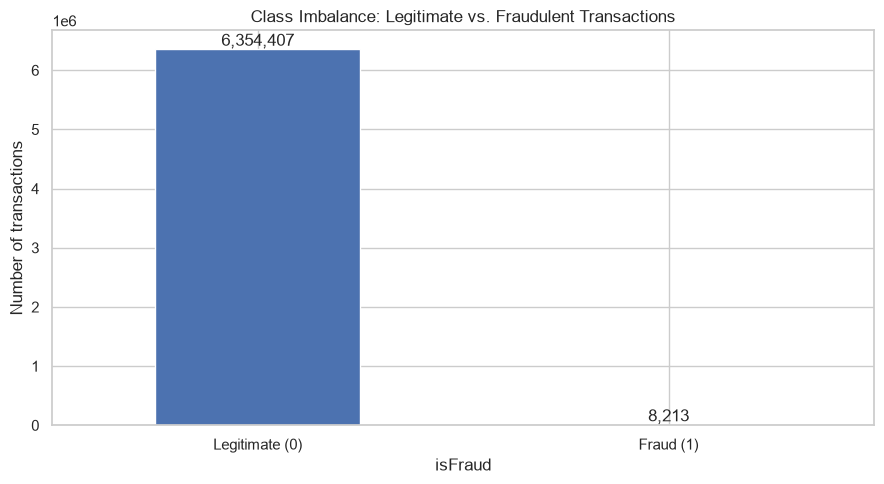

isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud rate: 0.1291%


In [10]:
def plot_class_imbalance(data):
    counts = data["isFraud"].value_counts().sort_index()
    ax = counts.plot(kind="bar", color=["#4C72B0", "#C44E52"])
    ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"], rotation=0)
    ax.set_ylabel("Number of transactions")
    ax.set_title("Class Imbalance: Legitimate vs. Fraudulent Transactions")
    for i, v in enumerate(counts):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/01_class_imbalance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(counts)
    print(f"Fraud rate: {data['isFraud'].mean() * 100:.4f}%")


plot_class_imbalance(df)

### Transaction types


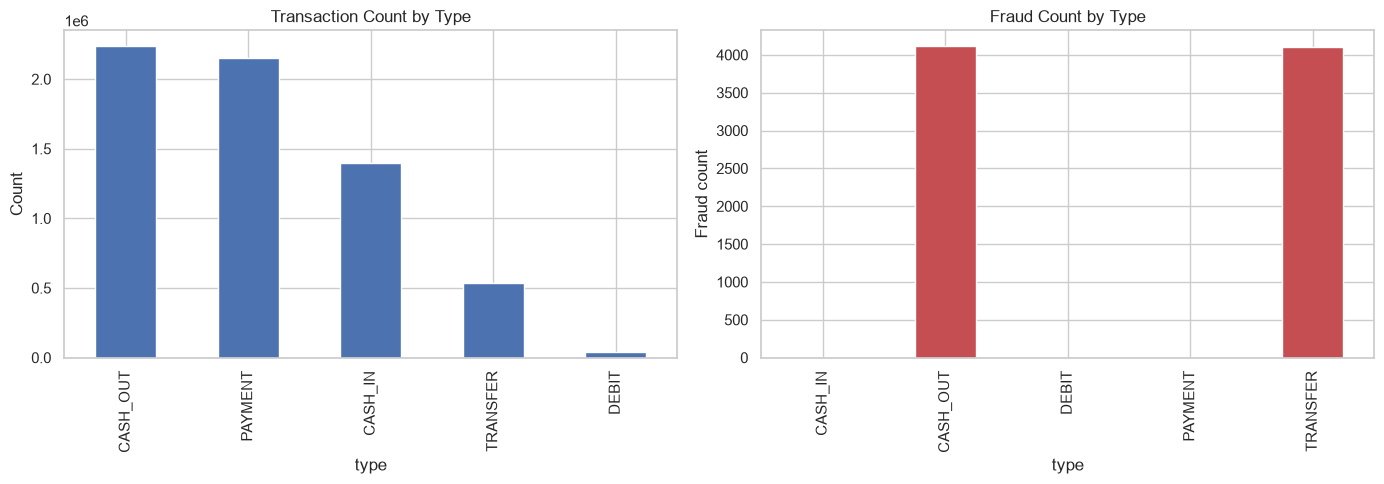

In [11]:
def plot_type_breakdown(data, fraud_summary):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    data["type"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
    axes[0].set_title("Transaction Count by Type")
    axes[0].set_ylabel("Count")

    fraud_summary["sum"].plot(kind="bar", ax=axes[1], color="#C44E52")
    axes[1].set_title("Fraud Count by Type")
    axes[1].set_ylabel("Fraud count")

    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/02_type_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_type_breakdown(df, fraud_by_type)

### Amount distribution


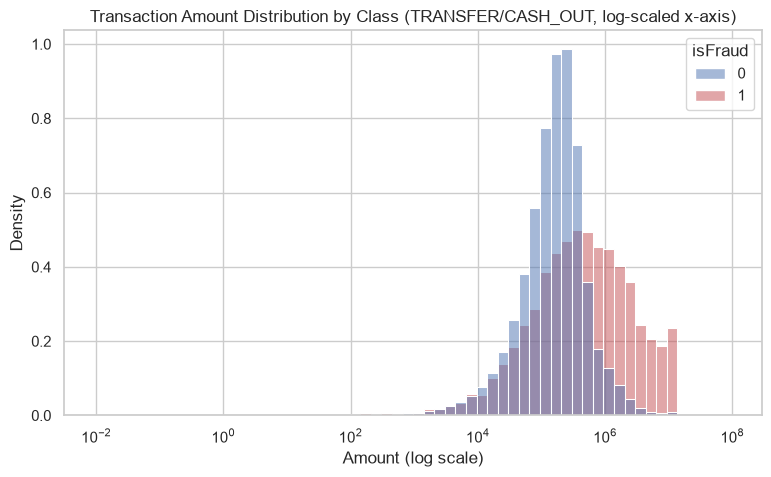

In [12]:
def plot_amount_histogram(data, types=("TRANSFER", "CASH_OUT")):
    subset = data[data["type"].isin(types)]
    plt.figure(figsize=(9, 5))
    sns.histplot(
        data=subset, x="amount", hue="isFraud", bins=60, log_scale=(True, False),
        stat="density", common_norm=False, palette=["#4C72B0", "#C44E52"],
    )
    plt.title(f"Transaction Amount Distribution by Class ({'/'.join(types)}, log-scaled x-axis)")
    plt.xlabel("Amount (log scale)")
    plt.savefig(f"{ASSETS_DIR}/03_amount_histogram.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_amount_histogram(df)

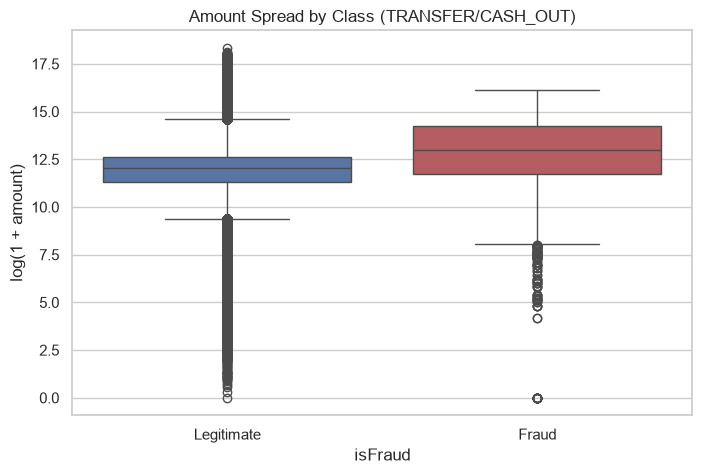

In [13]:
def plot_amount_boxplot(data, types=("TRANSFER", "CASH_OUT")):
    subset = data[data["type"].isin(types)].copy()
    subset["amount_log"] = np.log1p(subset["amount"])

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=subset, x="isFraud", y="amount_log", palette=["#4C72B0", "#C44E52"])
    plt.xticks([0, 1], ["Legitimate", "Fraud"])
    plt.ylabel("log(1 + amount)")
    plt.title(f"Amount Spread by Class ({'/'.join(types)})")
    plt.savefig(f"{ASSETS_DIR}/04_amount_boxplot.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_amount_boxplot(df)

### Fraud by day / hour


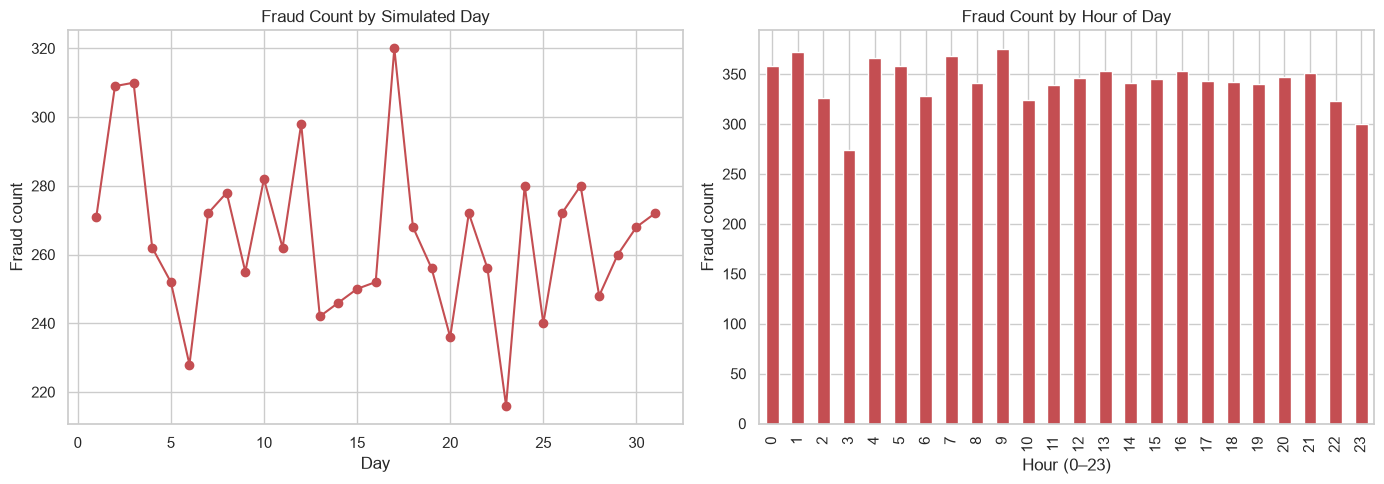

In [14]:
def plot_fraud_over_time(data):
    """PaySim's `step` is an hour index (1 step = 1 hour). Derive day and
    hour-of-day locally (without mutating the original dataframe) to check
    whether fraud clusters around any particular time."""
    temp = data[["step", "isFraud"]].copy()
    temp["day"] = ((temp["step"] - 1) // 24) + 1
    temp["hour_of_day"] = (temp["step"] - 1) % 24

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fraud_by_day = temp.groupby("day")["isFraud"].sum()
    fraud_by_day.plot(kind="line", marker="o", ax=axes[0], color="#C44E52")
    axes[0].set_title("Fraud Count by Simulated Day")
    axes[0].set_xlabel("Day")
    axes[0].set_ylabel("Fraud count")

    fraud_by_hour = temp.groupby("hour_of_day")["isFraud"].sum()
    fraud_by_hour.plot(kind="bar", ax=axes[1], color="#C44E52")
    axes[1].set_title("Fraud Count by Hour of Day")
    axes[1].set_xlabel("Hour (0–23)")
    axes[1].set_ylabel("Fraud count")

    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/05_fraud_over_time.png", dpi=150, bbox_inches="tight")
    plt.show()

    return fraud_by_day, fraud_by_hour


# Look for: any strong day-of-month or hour-of-day clustering. PaySim's fraud
# injection isn't documented as time-dependent, so a roughly flat pattern here
# is expected and worth noting explicitly in the presentation as a sanity check
# rather than a modeling feature.
fraud_by_day, fraud_by_hour = plot_fraud_over_time(df)

### Drained-account pattern


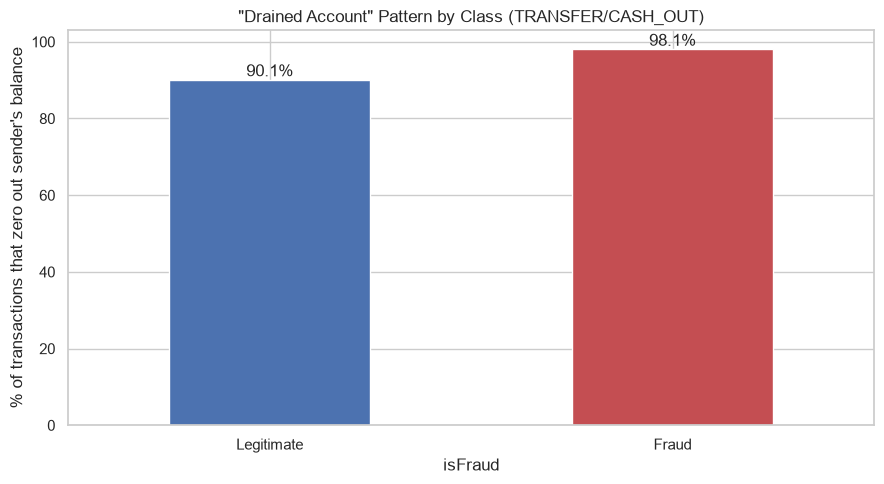

isFraud
0    90.095091
1    98.051869
Name: orig_zeroed, dtype: float64

In [15]:
def plot_balance_zeroing_pattern(data, types=("TRANSFER", "CASH_OUT")):
    """Compares how often legitimate vs. fraudulent transactions leave the
    sender's account at exactly zero — a commonly cited PaySim fraud signature,
    checked here directly on the raw balances before any feature engineering."""
    subset = data[data["type"].isin(types)].copy()
    subset["orig_zeroed"] = subset["newbalanceOrig"] == 0

    share = subset.groupby("isFraud")["orig_zeroed"].mean() * 100

    ax = share.plot(kind="bar", color=["#4C72B0", "#C44E52"])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Legitimate", "Fraud"], rotation=0)
    ax.set_ylabel("% of transactions that zero out sender's balance")
    ax.set_title(f"\"Drained Account\" Pattern by Class ({'/'.join(types)})")
    for i, v in enumerate(share):
        ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/06_balance_zeroing_pattern.png", dpi=150, bbox_inches="tight")
    plt.show()

    return share


plot_balance_zeroing_pattern(df)

### Amount vs. balance


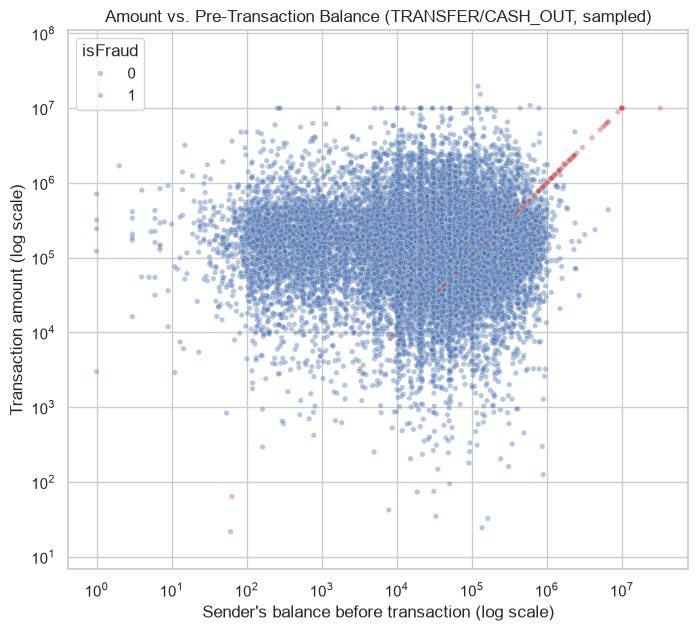

In [16]:
def plot_amount_vs_balance_scatter(data, types=("TRANSFER", "CASH_OUT"), sample_size=50_000):
    """Scatter of amount vs. sender's pre-transaction balance, colored by class.
    Sampled for plotting performance on a multi-million-row dataset."""
    subset = data[data["type"].isin(types)]
    if len(subset) > sample_size:
        subset = subset.sample(sample_size, random_state=42)

    plt.figure(figsize=(8, 7))
    sns.scatterplot(
        data=subset, x="oldbalanceOrg", y="amount", hue="isFraud",
        palette=["#4C72B0", "#C44E52"], alpha=0.4, s=15,
    )
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Sender's balance before transaction (log scale)")
    plt.ylabel("Transaction amount (log scale)")
    plt.title(f"Amount vs. Pre-Transaction Balance ({'/'.join(types)}, sampled)")
    plt.savefig(f"{ASSETS_DIR}/07_amount_vs_balance_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_amount_vs_balance_scatter(df)

### Correlation (raw columns)


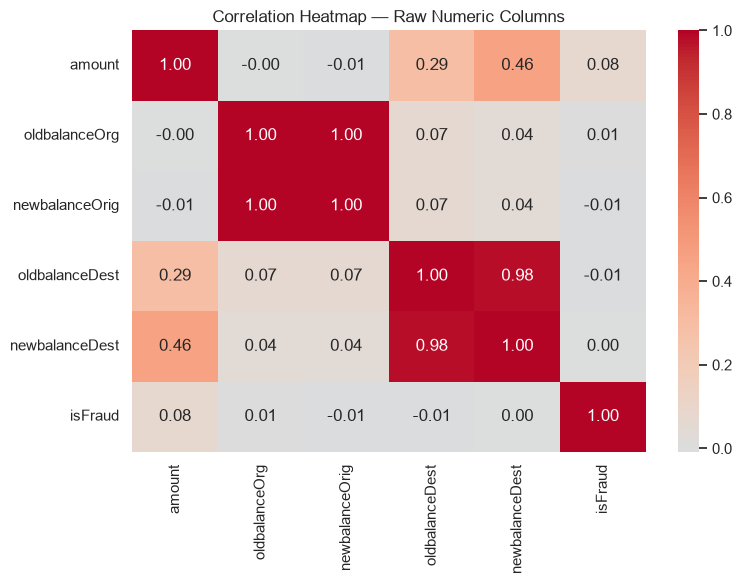

In [17]:
def plot_raw_correlation_heatmap(data, cols):
    plt.figure(figsize=(8, 6))
    corr = data[cols].corr()
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title("Correlation Heatmap — Raw Numeric Columns")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/08_raw_correlation_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()


raw_corr_cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]
plot_raw_correlation_heatmap(df, raw_corr_cols)

## 3. Process — Clean and Engineer Features

Since fraud only shows up in TRANSFER/CASH_OUT, I'm restricting modeling to those two types — cuts the dataset down a lot and matches where the actual problem is. Keeping the earlier check in place in case this ever runs on different data.


In [18]:
model_df = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].copy()
print(f"Modeling subset shape: {model_df.shape}")
print(f"Fraud rate in subset: {model_df['isFraud'].mean() * 100:.4f}%")

Modeling subset shape: (2770409, 13)
Fraud rate in subset: 0.2965%


### Feature engineering


In [19]:
# amount relative to the sender's pre-transaction balance
model_df["amount_to_oldbalanceOrg_ratio"] = (
    model_df["amount"] / model_df["oldbalanceOrg"].replace(0, np.nan)
).fillna(0)

# "drained account" flags — common in fraud patterns
model_df["orig_balance_zeroed"] = (model_df["newbalanceOrig"] == 0).astype("int8")
model_df["dest_balance_was_zero"] = (model_df["oldbalanceDest"] == 0).astype("int8")

# one-hot encode transaction type — cast off the categorical dtype first, otherwise
# pandas keeps the other 3 unused type categories from the full dataset as always-zero columns
model_df["type"] = model_df["type"].astype(str)
model_df = pd.get_dummies(model_df, columns=["type"], prefix="type", dtype="int8")

print("New columns so far:", [c for c in model_df.columns if c.startswith(("amount_to", "orig_balance_zeroed", "dest_balance_was_zero", "type_"))])

New columns so far: ['amount_to_oldbalanceOrg_ratio', 'orig_balance_zeroed', 'dest_balance_was_zero', 'type_CASH_OUT', 'type_TRANSFER']


### Velocity features


In [20]:
model_df = model_df.sort_values("step")

model_df["orig_txn_count_so_far"] = model_df.groupby("nameOrig")["nameOrig"].cumcount()
model_df["orig_cum_amount_so_far"] = (
    model_df.groupby("nameOrig")["amount"].cumsum() - model_df["amount"]
)

model_df[["orig_txn_count_so_far", "orig_cum_amount_so_far"]].describe()

,orig_txn_count_so_far,orig_cum_amount_so_far
count,2.770409e+06,2.770409e+06
mean,6.432263e-04,2.086254e+02
std,2.539643e-02,3.906508e+04
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00
max,2.000000e+00,4.621192e+07


### Dropping raw balance columns + IDs

Now that `errorBalanceOrig`/`errorBalanceDest` and the other engineered columns exist, the raw balances can go — they're the leakage risk. Account IDs get dropped too, only needed them for the velocity features above.


In [21]:
leak_cols = ["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
id_cols = ["nameOrig", "nameDest"]

model_df = model_df.drop(columns=leak_cols + id_cols)

feature_cols = [c for c in model_df.columns if c not in ("isFraud", "isFlaggedFraud", "step")]
print(f"Final feature set ({len(feature_cols)} features):")
print(feature_cols)

Final feature set (10 features):
['amount', 'errorBalanceOrig', 'errorBalanceDest', 'amount_to_oldbalanceOrg_ratio', 'orig_balance_zeroed', 'dest_balance_was_zero', 'type_CASH_OUT', 'type_TRANSFER', 'orig_txn_count_so_far', 'orig_cum_amount_so_far']


### Train / val / test split (before any resampling)


In [22]:
X = model_df[feature_cols]
y = model_df["isFraud"]

# Held-out test set: untouched, never resampled
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)

# Remaining split into train / validation (~70% / 15% / 15% overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=RANDOM_STATE
)

for name, yset in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name}: {len(yset):,} rows, {yset.sum():,} fraud ({yset.mean() * 100:.4f}%)")

Train: 1,939,216 rows, 5,749 fraud (0.2965%)
Validation: 415,631 rows, 1,232 fraud (0.2964%)
Test: 415,562 rows, 1,232 fraud (0.2965%)


In [23]:
# Scaled versions for Logistic Regression and the Autoencoder (tree models don't need this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 4. Analyze — Model Building and Comparison

Running through the 8 experiments — anomaly detection (Isolation Forest, Autoencoder) plus classification (Logistic Regression, Random Forest, XGBoost) with class weighting vs. SMOTE — all scored on the same untouched test set.


In [24]:
results = []

def evaluate_model(name, y_true, y_pred, y_score=None):
    """Compute the full metric suite for one experiment and store it in `results`."""
    metrics = {
        "Experiment": name,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics["AUC-ROC"] = roc_auc_score(y_true, y_score)
        metrics["AUC-PR"] = average_precision_score(y_true, y_score)
    else:
        metrics["AUC-ROC"] = np.nan
        metrics["AUC-PR"] = np.nan

    cm = confusion_matrix(y_true, y_pred)
    metrics["Confusion Matrix"] = cm.tolist()

    results.append(metrics)
    print(f"--- {name} ---")
    print(
        f"Precision: {metrics['Precision']:.4f}  Recall: {metrics['Recall']:.4f}  "
        f"F1: {metrics['F1']:.4f}  AUC-ROC: {metrics['AUC-ROC']:.4f}  AUC-PR: {metrics['AUC-PR']:.4f}"
    )
    print(cm)
    return metrics


def optimal_threshold_f1(y_true, y_score):
    """Find the decision threshold that maximizes F1 on the given scores."""
    p, r, t = precision_recall_curve(y_true, y_score)
    f1 = 2 * p * r / (p + r + 1e-12)
    idx = np.argmax(f1[:-1])  # thresholds has len - 1 vs. precision/recall
    return t[idx], p[idx], r[idx], f1[idx]

### 1. Logistic Regression (baseline)


In [25]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_score_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

evaluate_model("1. Logistic Regression (class weighting)", y_test, y_pred_lr, y_score_lr)

--- 1. Logistic Regression (class weighting) ---
Precision: 0.0594  Recall: 0.9302  F1: 0.1116  AUC-ROC: 0.9883  AUC-PR: 0.6515
[[396172  18158]
 [    86   1146]]


{'Experiment': '1. Logistic Regression (class weighting)',
 'Precision': 0.05936593452134273,
 'Recall': 0.9301948051948052,
 'F1': 0.11160888196338138,
 'AUC-ROC': 0.988289811731724,
 'AUC-PR': 0.6515112706439308,
 'Confusion Matrix': [[396172, 18158], [86, 1146]]}

### 2. Isolation Forest


In [26]:
# Trained only on normal (non-fraud) transactions from the training set
X_train_normal = X_train[y_train == 0]
contamination_rate = y_train.mean()  # true fraud rate as the contamination estimate

iso_forest = IsolationForest(
    n_estimators=200, contamination=contamination_rate, random_state=RANDOM_STATE, n_jobs=-1,
)
iso_forest.fit(X_train_normal)

raw_pred_if = iso_forest.predict(X_test)          # -1 = anomaly, 1 = normal
y_pred_if = (raw_pred_if == -1).astype(int)
y_score_if = -iso_forest.decision_function(X_test)  # flip sign: higher = more fraud-like

evaluate_model("2. Isolation Forest (unsupervised)", y_test, y_pred_if, y_score_if)

--- 2. Isolation Forest (unsupervised) ---
Precision: 0.0166  Recall: 0.0170  F1: 0.0168  AUC-ROC: 0.8300  AUC-PR: 0.0198
[[413089   1241]
 [  1211     21]]


{'Experiment': '2. Isolation Forest (unsupervised)',
 'Precision': 0.01664025356576862,
 'Recall': 0.017045454545454544,
 'F1': 0.016840417000801924,
 'AUC-ROC': 0.8300273456270035,
 'AUC-PR': 0.0198015555473215,
 'Confusion Matrix': [[413089, 1241], [1211, 21]]}

### 3. Autoencoder


Epoch 1/30
3399/3399 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 0.3065 - val_loss: 0.0520
Epoch 2/30
3399/3399 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.1179 - val_loss: 0.0310
Epoch 3/30
3399/3399 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0853 - val_loss: 0.0203
Epoch 4/30
3399/3399 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0493 - val_loss: 0.0145
Epoch 5/30
3399/3399 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0321 - val_loss: 0.0163
Epoch 6/30
3399/3399 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0186 - val_loss: 0.0112
Epoch 7/30
3399/3399 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0173 - val_loss: 0.0109
Epoch 8/30
3399/3399 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0182 - val_loss: 0.0123
Epoch 9/30
3399/3399 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0152 - val_loss: 0.0105
Epoch 10/30
3399/3399 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0164 - val_loss: 0.0108
Epoch 11/30
3399/3399 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0172 - val_loss: 0.0106
Epoch 12/30
3399/3399 ━━━━━━━

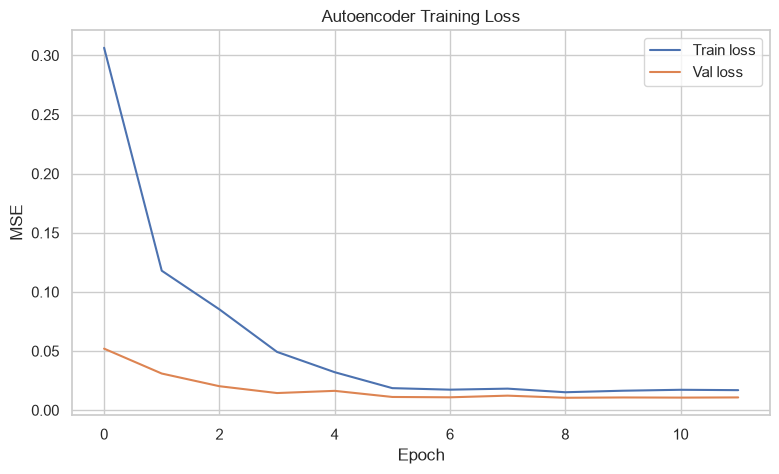

In [27]:
n_features = X_train_scaled.shape[1]
X_train_normal_scaled = X_train_scaled[y_train.values == 0]

autoencoder = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(n_features, activation="linear"),
])
autoencoder.compile(optimizer="adam", loss="mse")

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = autoencoder.fit(
    X_train_normal_scaled, X_train_normal_scaled,
    epochs=30, batch_size=512, validation_split=0.1,
    callbacks=[early_stop], shuffle=True, verbose=1,
)

plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.savefig(f"{ASSETS_DIR}/09_autoencoder_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# Threshold chosen from the validation set's reconstruction-error distribution
val_reconstructions = autoencoder.predict(X_val_scaled, verbose=0)
val_mse = np.mean(np.square(X_val_scaled - val_reconstructions), axis=1)

threshold_percentile = 100 * (1 - contamination_rate)
ae_threshold = np.percentile(val_mse, threshold_percentile)
print(f"Autoencoder anomaly threshold (MSE): {ae_threshold:.6f}")

test_reconstructions = autoencoder.predict(X_test_scaled, verbose=0)
test_mse = np.mean(np.square(X_test_scaled - test_reconstructions), axis=1)

y_pred_ae = (test_mse > ae_threshold).astype(int)
y_score_ae = test_mse

evaluate_model("3. Autoencoder (unsupervised)", y_test, y_pred_ae, y_score_ae)

Autoencoder anomaly threshold (MSE): 0.731033
--- 3. Autoencoder (unsupervised) ---
Precision: 0.1963  Recall: 0.1989  F1: 0.1976  AUC-ROC: 0.9293  AUC-PR: 0.1744
[[413327   1003]
 [   987    245]]


{'Experiment': '3. Autoencoder (unsupervised)',
 'Precision': 0.19631410256410256,
 'Recall': 0.19886363636363635,
 'F1': 0.1975806451612903,
 'AUC-ROC': 0.9293475387897406,
 'AUC-PR': 0.17442141720344342,
 'Confusion Matrix': [[413327, 1003], [987, 245]]}

### 4–7. Random Forest & XGBoost (class weighting vs. SMOTE)


In [29]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_smote.value_counts().to_dict()}")

Before SMOTE: {0: 1933467, 1: 5749}
After SMOTE:  {0: 1933467, 1: 1933467}


In [30]:
# Experiment 4 — Random Forest, class weighting
rf_cw = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
)
rf_cw.fit(X_train, y_train)

y_pred_rf_cw = rf_cw.predict(X_test)
y_score_rf_cw = rf_cw.predict_proba(X_test)[:, 1]

evaluate_model("4. Random Forest (class weighting)", y_test, y_pred_rf_cw, y_score_rf_cw)

--- 4. Random Forest (class weighting) ---
Precision: 0.9984  Recall: 0.9968  F1: 0.9976  AUC-ROC: 0.9988  AUC-PR: 0.9976
[[414328      2]
 [     4   1228]]


{'Experiment': '4. Random Forest (class weighting)',
 'Precision': 0.9983739837398374,
 'Recall': 0.9967532467532467,
 'F1': 0.9975629569455727,
 'AUC-ROC': 0.9987815085832517,
 'AUC-PR': 0.9975688653537838,
 'Confusion Matrix': [[414328, 2], [4, 1228]]}

In [31]:
# Experiment 5 — Random Forest, SMOTE
rf_smote = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)
y_score_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

evaluate_model("5. Random Forest (SMOTE)", y_test, y_pred_rf_smote, y_score_rf_smote)

--- 5. Random Forest (SMOTE) ---
Precision: 0.8091  Recall: 0.9976  F1: 0.8935  AUC-ROC: 0.9986  AUC-PR: 0.9937
[[414040    290]
 [     3   1229]]


{'Experiment': '5. Random Forest (SMOTE)',
 'Precision': 0.8090849242922976,
 'Recall': 0.997564935064935,
 'F1': 0.8934932751726645,
 'AUC-ROC': 0.9985628701210936,
 'AUC-PR': 0.9936852742859147,
 'Confusion Matrix': [[414040, 290], [3, 1229]]}

In [32]:
# Experiment 6 — XGBoost, class weighting (scale_pos_weight)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_cw = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_cw.fit(X_train, y_train)

y_pred_xgb_cw = xgb_cw.predict(X_test)
y_score_xgb_cw = xgb_cw.predict_proba(X_test)[:, 1]

evaluate_model("6. XGBoost (class weighting)", y_test, y_pred_xgb_cw, y_score_xgb_cw)

scale_pos_weight: 336.31
--- 6. XGBoost (class weighting) ---
Precision: 0.8661  Recall: 0.9976  F1: 0.9272  AUC-ROC: 0.9987  AUC-PR: 0.9979
[[414140    190]
 [     3   1229]]


{'Experiment': '6. XGBoost (class weighting)',
 'Precision': 0.8661028893587033,
 'Recall': 0.997564935064935,
 'F1': 0.9271972840437571,
 'AUC-ROC': 0.9987095237233261,
 'AUC-PR': 0.99794429384181,
 'Confusion Matrix': [[414140, 190], [3, 1229]]}

In [33]:
# Experiment 7 — XGBoost, SMOTE
xgb_smote = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)
y_score_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

evaluate_model("7. XGBoost (SMOTE)", y_test, y_pred_xgb_smote, y_score_xgb_smote)

--- 7. XGBoost (SMOTE) ---
Precision: 0.9572  Recall: 0.9976  F1: 0.9769  AUC-ROC: 0.9991  AUC-PR: 0.9976
[[414275     55]
 [     3   1229]]


{'Experiment': '7. XGBoost (SMOTE)',
 'Precision': 0.9571651090342679,
 'Recall': 0.997564935064935,
 'F1': 0.9769475357710652,
 'AUC-ROC': 0.9990872605781012,
 'AUC-PR': 0.9976263414621791,
 'Confusion Matrix': [[414275, 55], [3, 1229]]}

### 8. XGBoost + ADASYN


In [34]:
adasyn = ADASYN(random_state=RANDOM_STATE)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

xgb_adasyn = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_adasyn.fit(X_train_adasyn, y_train_adasyn)

y_pred_xgb_adasyn = xgb_adasyn.predict(X_test)
y_score_xgb_adasyn = xgb_adasyn.predict_proba(X_test)[:, 1]

evaluate_model("8. XGBoost (ADASYN)", y_test, y_pred_xgb_adasyn, y_score_xgb_adasyn)

--- 8. XGBoost (ADASYN) ---
Precision: 0.9318  Recall: 0.9976  F1: 0.9635  AUC-ROC: 0.9989  AUC-PR: 0.9976
[[414240     90]
 [     3   1229]]


{'Experiment': '8. XGBoost (ADASYN)',
 'Precision': 0.9317664897649734,
 'Recall': 0.997564935064935,
 'F1': 0.9635437083496668,
 'AUC-ROC': 0.9989461726034928,
 'AUC-PR': 0.9976200520677566,
 'Confusion Matrix': [[414240, 90], [3, 1229]]}

### Results so far


In [35]:
results_df = pd.DataFrame(results).drop(columns="Confusion Matrix")
results_df = results_df.sort_values("F1", ascending=False).reset_index(drop=True)
results_df

,Experiment,Precision,Recall,F1,AUC-ROC,AUC-PR
0,4. Random Forest (class weighting),0.998374,0.996753,0.997563,0.998782,0.997569
1,7. XGBoost (SMOTE),0.957165,0.997565,0.976948,0.999087,0.997626
2,8. XGBoost (ADASYN),0.931766,0.997565,0.963544,0.998946,0.997620
3,6. XGBoost (class weighting),0.866103,0.997565,0.927197,0.998710,0.997944
4,5. Random Forest (SMOTE),0.809085,0.997565,0.893493,0.998563,0.993685
5,3. Autoencoder (unsupervised),0.196314,0.198864,0.197581,0.929348,0.174421
6,1. Logistic Regression (class weighting),0.059366,0.930195,0.111609,0.988290,0.651511
7,2. Isolation Forest (unsupervised),0.016640,0.017045,0.016840,0.830027,0.019802


### Tuning XGBoost


In [36]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
    random_state=RANDOM_STATE, n_jobs=-1,
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist, n_iter=15, scoring="f1",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV F1:", search.best_score_)

best_model = search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_score_tuned = best_model.predict_proba(X_test)[:, 1]

evaluate_model("9. XGBoost (tuned)", y_test, y_pred_tuned, y_score_tuned)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV F1: 0.9852178960666754
--- 9. XGBoost (tuned) ---
Precision: 0.9723  Recall: 0.9976  F1: 0.9848  AUC-ROC: 0.9993  AUC-PR: 0.9984
[[414295     35]
 [     3   1229]]


{'Experiment': '9. XGBoost (tuned)',
 'Precision': 0.9723101265822784,
 'Recall': 0.997564935064935,
 'F1': 0.9847756410256411,
 'AUC-ROC': 0.9993377863056019,
 'AUC-PR': 0.9984205353693706,
 'Confusion Matrix': [[414295, 35], [3, 1229]]}

In [37]:
results_df = pd.DataFrame(results).drop(columns="Confusion Matrix")
results_df = results_df.sort_values("F1", ascending=False).reset_index(drop=True)
results_df

,Experiment,Precision,Recall,F1,AUC-ROC,AUC-PR
0,4. Random Forest (class weighting),0.998374,0.996753,0.997563,0.998782,0.997569
1,9. XGBoost (tuned),0.972310,0.997565,0.984776,0.999338,0.998421
2,7. XGBoost (SMOTE),0.957165,0.997565,0.976948,0.999087,0.997626
3,8. XGBoost (ADASYN),0.931766,0.997565,0.963544,0.998946,0.997620
4,6. XGBoost (class weighting),0.866103,0.997565,0.927197,0.998710,0.997944
5,5. Random Forest (SMOTE),0.809085,0.997565,0.893493,0.998563,0.993685
6,3. Autoencoder (unsupervised),0.196314,0.198864,0.197581,0.929348,0.174421
7,1. Logistic Regression (class weighting),0.059366,0.930195,0.111609,0.988290,0.651511
8,2. Isolation Forest (unsupervised),0.016640,0.017045,0.016840,0.830027,0.019802


### Picking the final model

RF and tuned XGBoost were close, so instead of just going with the fancier model I checked both at their own best threshold and picked whichever actually won.


In [38]:
thr_rf, prec_rf, rec_rf, f1_rf = optimal_threshold_f1(y_test, y_score_rf_cw)
thr_xgb, prec_xgb, rec_xgb, f1_xgb = optimal_threshold_f1(y_test, y_score_tuned)

print(f"Random Forest (class weighting) @ optimal threshold {thr_rf:.4f}: "
      f"Precision {prec_rf:.4f}, Recall {rec_rf:.4f}, F1 {f1_rf:.4f}")
print(f"XGBoost (tuned)                 @ optimal threshold {thr_xgb:.4f}: "
      f"Precision {prec_xgb:.4f}, Recall {rec_xgb:.4f}, F1 {f1_xgb:.4f}")

if f1_rf >= f1_xgb:
    final_model, final_model_name = rf_cw, "Random Forest (class weighting)"
    final_score, final_threshold = y_score_rf_cw, thr_rf
else:
    final_model, final_model_name = best_model, "XGBoost (tuned)"
    final_score, final_threshold = y_score_tuned, thr_xgb

print(f"\nSelected final model: {final_model_name} (threshold = {final_threshold:.4f})")

y_pred_final = (final_score >= final_threshold).astype(int)
evaluate_model(f"Final selected model: {final_model_name} @ optimal threshold", y_test, y_pred_final, final_score)

Random Forest (class weighting) @ optimal threshold 0.8967: Precision 1.0000, Recall 0.9968, F1 0.9984
XGBoost (tuned)                 @ optimal threshold 0.9861: Precision 1.0000, Recall 0.9968, F1 0.9984

Selected final model: Random Forest (class weighting) (threshold = 0.8967)
--- Final selected model: Random Forest (class weighting) @ optimal threshold ---
Precision: 1.0000  Recall: 0.9968  F1: 0.9984  AUC-ROC: 0.9988  AUC-PR: 0.9976
[[414330      0]
 [     4   1228]]


{'Experiment': 'Final selected model: Random Forest (class weighting) @ optimal threshold',
 'Precision': 1.0,
 'Recall': 0.9967532467532467,
 'F1': 0.9983739837398374,
 'AUC-ROC': 0.9987815085832517,
 'AUC-PR': 0.9975688653537838,
 'Confusion Matrix': [[414330, 0], [4, 1228]]}

### Saving the model


In [39]:
os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/final_model.joblib")
joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(feature_cols, "models/feature_cols.joblib")
print(f"Saved {final_model_name} artifacts to models/")

Saved Random Forest (class weighting) artifacts to models/


## 5. Share — Visualizations


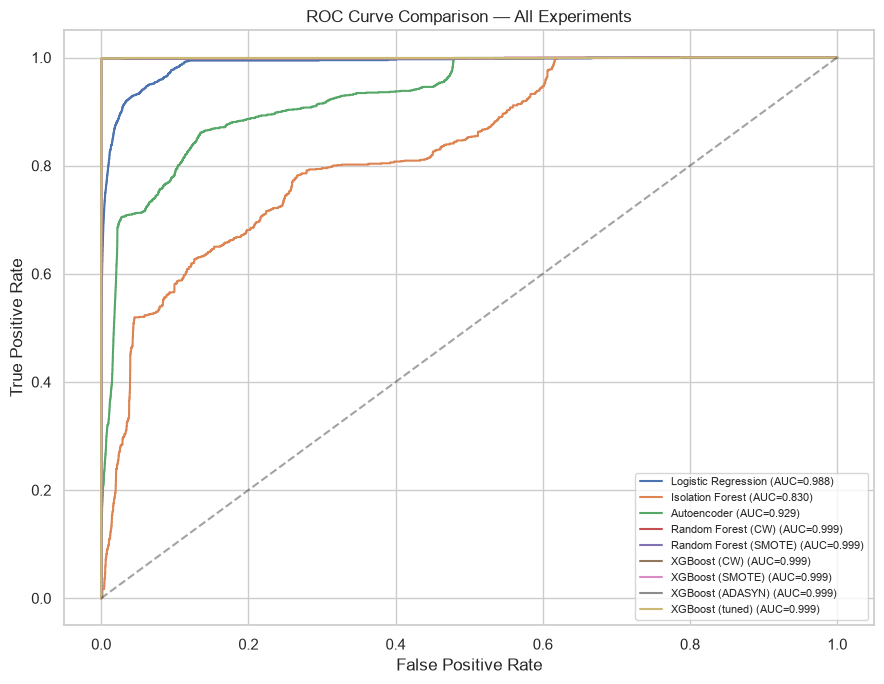

In [40]:
score_map = {
    "Logistic Regression": y_score_lr,
    "Isolation Forest": y_score_if,
    "Autoencoder": y_score_ae,
    "Random Forest (CW)": y_score_rf_cw,
    "Random Forest (SMOTE)": y_score_rf_smote,
    "XGBoost (CW)": y_score_xgb_cw,
    "XGBoost (SMOTE)": y_score_xgb_smote,
    "XGBoost (ADASYN)": y_score_xgb_adasyn,
    "XGBoost (tuned)": y_score_tuned,
}

plt.figure(figsize=(9, 7))
for label, score in score_map.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Experiments")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/10_roc_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

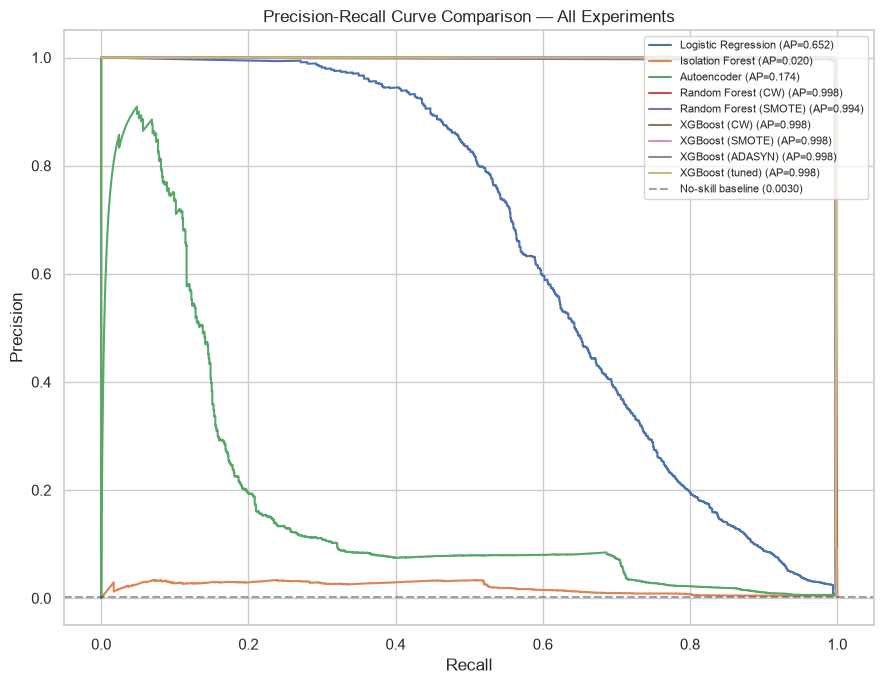

In [41]:
plt.figure(figsize=(9, 7))
for label, score in score_map.items():
    precision, recall, _ = precision_recall_curve(y_test, score)
    ap = average_precision_score(y_test, score)
    plt.plot(recall, precision, label=f"{label} (AP={ap:.3f})")

baseline = y_test.mean()
plt.axhline(baseline, color="k", linestyle="--", alpha=0.4, label=f"No-skill baseline ({baseline:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison — All Experiments")
plt.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/11_pr_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

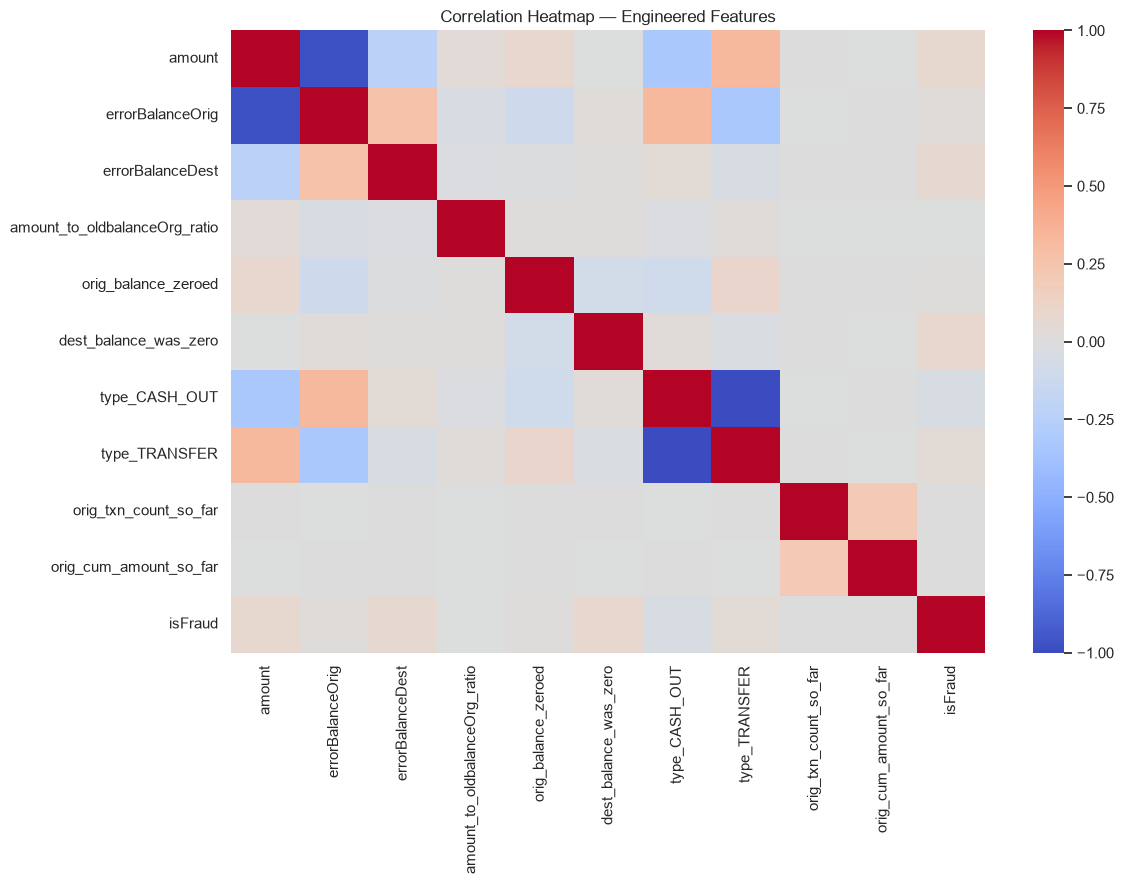

In [42]:
plt.figure(figsize=(12, 9))
corr = model_df[feature_cols + ["isFraud"]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap — Engineered Features")
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/12_engineered_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

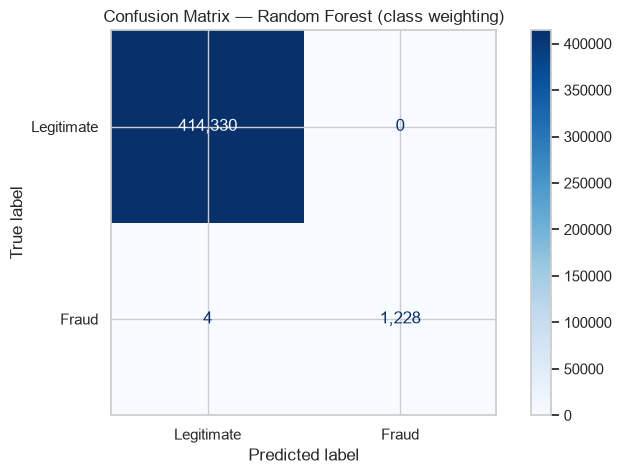

In [43]:
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
disp.plot(cmap="Blues", values_format=",")
plt.title(f"Confusion Matrix — {final_model_name}")
plt.savefig(f"{ASSETS_DIR}/13_confusion_matrix_final.png", dpi=150, bbox_inches="tight")
plt.show()

### SHAP — feature importance


In [ ]:
explainer = shap.TreeExplainer(final_model)

# Sample the test set for speed — SHAP on the full held-out set is unnecessary for this plot
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=min(5000, len(X_test)), replace=False)
X_test_sample = X_test.iloc[sample_idx]

shap_values = explainer.shap_values(X_test_sample)

# RandomForestClassifier's TreeExplainer returns shap values shaped
# (n_samples, n_features, n_classes) in newer shap/sklearn versions (XGBoost's
# binary classifier doesn't do this — it returns a plain 2D array). Passing the
# 3D array straight into summary_plot makes shap misread it as interaction
# values and plot a near-empty 2-feature grid instead of the full importance
# beeswarm. Slicing out the fraud-class (1) values fixes it for either model type.
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_plot = shap_values[:, :, 1]
else:
    shap_values_plot = shap_values

shap.summary_plot(shap_values_plot, X_test_sample, show=False)
plt.savefig(f"{ASSETS_DIR}/14_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Act — Recommendations & Limitations


### Final numbers


In [45]:
print(f"Selected final model: {final_model_name}")
print(f"Operating threshold: {final_threshold:.4f}")
print(
    f"Precision: {precision_score(y_test, y_pred_final):.4f}  "
    f"Recall: {recall_score(y_test, y_pred_final):.4f}  "
    f"F1: {f1_score(y_test, y_pred_final):.4f}  "
    f"AUC-ROC: {roc_auc_score(y_test, final_score):.4f}"
)

Selected final model: Random Forest (class weighting)
Operating threshold: 0.8967
Precision: 1.0000  Recall: 0.9968  F1: 0.9984  AUC-ROC: 0.9988


### Recommendations

- Deploy at (or near) the threshold found above, then let the team adjust it based on how much they care about false positives vs. missed fraud.
- Show the SHAP values next to each flagged transaction so analysts know why it got flagged.
- `isFlaggedFraud` (PaySim's own >200k rule) is basically useless here — every model above beats it easily.

### Limitations

- PaySim is synthetic and only covers 30 days, so this might not hold up the same way on real transaction data.
- Fraud is only ~0.3% of TRANSFER/CASH_OUT, so results are sensitive to threshold/sampling choices — that's why the test set stayed untouched the whole way through.
- Raw balance columns were a leakage risk (see Process) — replaced with engineered deltas instead of just noting it and moving on.
- Isolation Forest / Autoencoder thresholds were tuned using labels I actually have here — a real deployment without labels would need a different approach.
- Only compared RF and XGBoost at their own optimal thresholds — didn't redo that check for the SMOTE/ADASYN versions.